# Data Preprocessing & Train/Val/Test Split

Purpose: Prepare raw brain MRI images for deep learning by:
1. Resizing all images to uniform dimensions (224x224 pixels)
2. Converting grayscale images to 3-channel RGB format
3. Splitting dataset into Train/Validation/Test sets using 70/15/15 ratio

---

Split Strategy:
- Train: 70% (2100 images) - For model learning
- Validation: 15% (450 images) - For hyperparameter tuning
- Test: 15% (450 images) - For final model evaluation

---

## 1. Import Libraries and Setup Paths

In [8]:
import os
import shutil
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

# Source paths (raw dataset)
no_path = "dataset/no"
yes_path = "dataset/yes"

# Destination path (processed dataset)
output_base = "dataset_processed"

# WARNING: Remove old processed data to avoid mixing old and new splits
if os.path.exists(output_base):
    print(f"Removing existing processed dataset at '{output_base}'...")
    shutil.rmtree(output_base)
    print("Old data removed successfully.")

# Create fresh directory structure
os.makedirs(output_base, exist_ok=True)

# Define split folders and class labels
splits = ["train", "val", "test"]
classes = ["no", "yes"]

# Create directory structure for processed dataset
for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(output_base, split, cls), exist_ok=True)

print("\nFresh directory structure created successfully.")
print(f"Output directory: {output_base}/")
print(f"  train/")
print(f"    no/")
print(f"    yes/")
print(f"  val/")
print(f"    no/")
print(f"    yes/")
print(f"  test/")
print(f"    no/")
print(f"    yes/")


def resize_and_save(files, src_folder, dest_folder, size=(224, 224)):
    """
    Resize images and save to destination folder.
    
    Args:
        files (list): List of filenames to process
        src_folder (str): Source directory path
        dest_folder (str): Destination directory path
        size (tuple): Target image size (width, height)
    
    Returns:
        int: Number of images successfully processed
    """
    processed_count = 0
    
    for file in files:
        try:
            # Load image and convert to RGB (3 channels required for pretrained models)
            img = Image.open(os.path.join(src_folder, file)).convert("RGB")
            
            # Resize using bilinear interpolation
            img = img.resize(size, Image.BILINEAR)
            
            # Save to destination
            img.save(os.path.join(dest_folder, file))
            processed_count += 1
            
        except Exception as e:
            print(f"Error processing {file}: {e}")
    
    return processed_count


# ========================================
# SPLIT DATASET: 70% Train / 15% Val / 15% Test
# ========================================

print("\n" + "=" * 60)
print("SPLITTING DATASET (70/15/15)")
print("=" * 60)

for cls, path in zip(classes, [no_path, yes_path]):
    # Get all image files
    all_files = sorted(os.listdir(path))
    total = len(all_files)
    
    print(f"\nProcessing class: '{cls.upper()}'")
    print(f"  Total images: {total}")
    
    # First split: 70% train, 30% temp (for val+test)
    # Using stratified split with fixed random_state for reproducibility
    train_files, temp_files = train_test_split(
        all_files, 
        test_size=0.30,  # 30% for val+test
        random_state=42
    )
    
    # Second split: Split the 30% into 15% val and 15% test
    val_files, test_files = train_test_split(
        temp_files,
        test_size=0.50,  # 50% of 30% = 15% of total
        random_state=42
    )
    
    print(f"  Train: {len(train_files)} images ({len(train_files)/total*100:.1f}%)")
    print(f"  Val:   {len(val_files)} images ({len(val_files)/total*100:.1f}%)")
    print(f"  Test:  {len(test_files)} images ({len(test_files)/total*100:.1f}%)")
    
    # Resize and save images to respective folders
    print(f"  Resizing and saving images...")
    
    train_count = resize_and_save(train_files, path, os.path.join(output_base, "train", cls))
    val_count = resize_and_save(val_files, path, os.path.join(output_base, "val", cls))
    test_count = resize_and_save(test_files, path, os.path.join(output_base, "test", cls))
    
    print(f"  Saved: {train_count} train, {val_count} val, {test_count} test")

print("\n" + "=" * 60)
print("PREPROCESSING COMPLETE")
print("=" * 60)

# Display final summary
print("\nFINAL DATASET SUMMARY:")
for split in splits:
    no_count = len(os.listdir(os.path.join(output_base, split, "no")))
    yes_count = len(os.listdir(os.path.join(output_base, split, "yes")))
    total_count = no_count + yes_count
    print(f"  {split.upper():5s}: {total_count:4d} images (no={no_count}, yes={yes_count})")

print("\n" + "=" * 60)
print("VERIFICATION:")
expected = {"train": 2100, "val": 450, "test": 450}
for split in splits:
    actual = len(os.listdir(os.path.join(output_base, split, "no"))) + len(os.listdir(os.path.join(output_base, split, "yes")))
    status = "PASS" if actual == expected[split] else "FAIL"
    print(f"  [{status}] {split.upper()}: Expected {expected[split]}, Got {actual}")
print("=" * 60)

print("\nDataset is ready for CNN training.")


Fresh directory structure created successfully.
Output directory: dataset_processed/
  train/
    no/
    yes/
  val/
    no/
    yes/
  test/
    no/
    yes/

SPLITTING DATASET (70/15/15)

Processing class: 'NO'
  Total images: 1500
  Train: 1050 images (70.0%)
  Val:   225 images (15.0%)
  Test:  225 images (15.0%)
  Resizing and saving images...
  Saved: 1050 train, 225 val, 225 test

Processing class: 'YES'
  Total images: 1500
  Train: 1050 images (70.0%)
  Val:   225 images (15.0%)
  Test:  225 images (15.0%)
  Resizing and saving images...
  Saved: 1050 train, 225 val, 225 test

PREPROCESSING COMPLETE

FINAL DATASET SUMMARY:
  TRAIN: 2100 images (no=1050, yes=1050)
  VAL  :  450 images (no=225, yes=225)
  TEST :  450 images (no=225, yes=225)

VERIFICATION:
  [PASS] TRAIN: Expected 2100, Got 2100
  [PASS] VAL: Expected 450, Got 450
  [PASS] TEST: Expected 450, Got 450

Dataset is ready for CNN training.


---

## 2. Visual Verification: Display Sample Images

Verify that preprocessing was successful by displaying random samples from each split.

Visual Verification of Preprocessed Images


TRAIN Set:


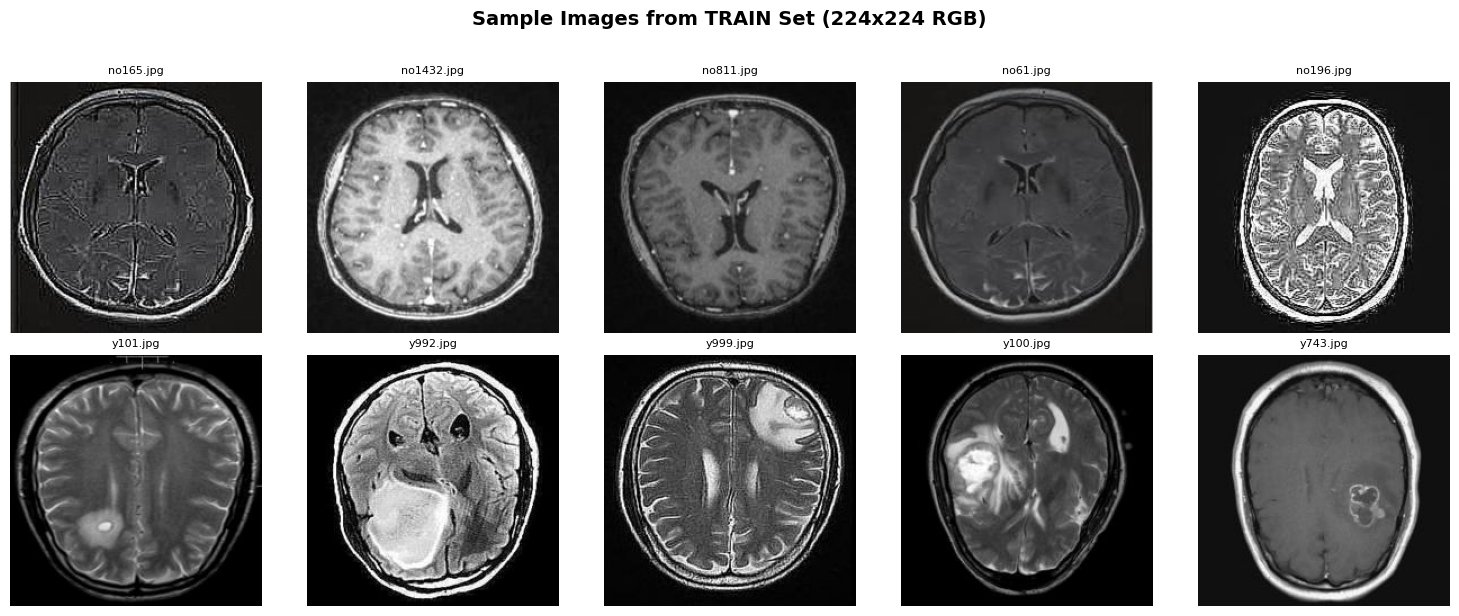


VAL Set:


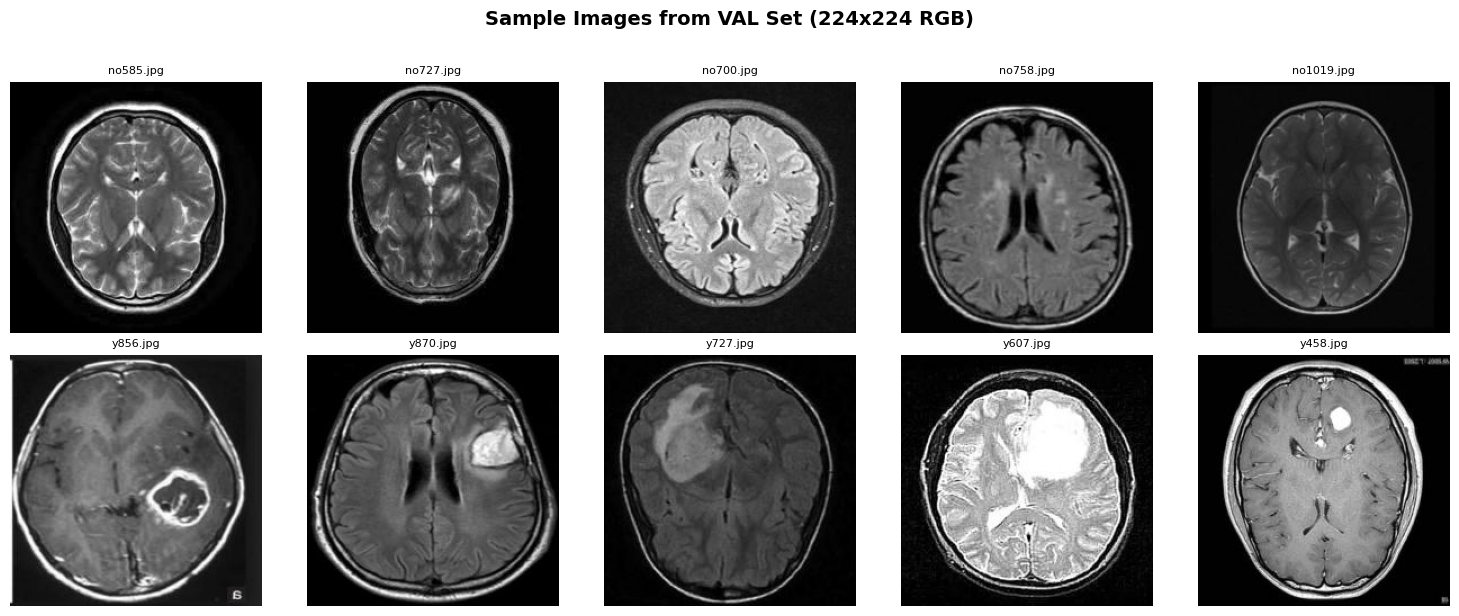


TEST Set:


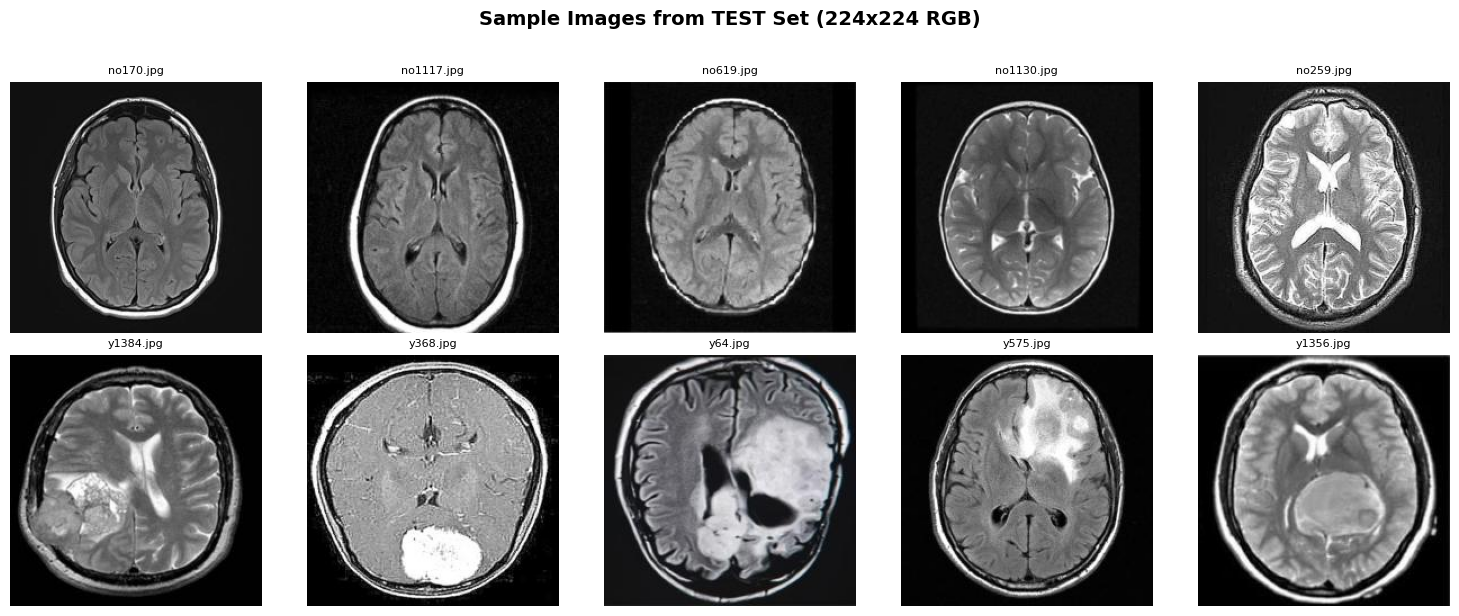

In [9]:
import matplotlib.pyplot as plt

def show_sample_images(base_path, split="train", n=5):
    """
    Display random sample images from a specific split.
    
    Args:
        base_path (str): Base directory of processed dataset
        split (str): Which split to visualize ('train', 'val', or 'test')
        n (int): Number of samples to display per class
    """
    fig = plt.figure(figsize=(15, 6))
    
    for i, cls in enumerate(["no", "yes"]):
        cls_path = os.path.join(base_path, split, cls)
        files = np.random.choice(os.listdir(cls_path), n, replace=False)
        
        for j, file in enumerate(files):
            img = Image.open(os.path.join(cls_path, file))
            
            plt.subplot(2, n, i*n + j + 1)
            plt.imshow(img)
            plt.axis("off")
            
            # Label the first image of each row
            if j == 0:
                plt.ylabel(f"Class: {cls.upper()}", fontsize=12, fontweight='bold')
            
            # Add filename as title (small font)
            plt.title(file, fontsize=8)
    
    plt.suptitle(f"Sample Images from {split.upper()} Set (224x224 RGB)", 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Display samples from all splits
print("Visual Verification of Preprocessed Images\n")
print("=" * 60)

for split in ["train", "val", "test"]:
    print(f"\n{split.upper()} Set:")
    show_sample_images("dataset_processed", split, n=5)

---

## 3. Pixel Intensity Statistics

Analyze pixel intensity distributions after preprocessing to ensure data quality and guide normalization strategy.

In [10]:
base_path = "dataset_processed"

def pixel_stats(folder, n_samples=100):
    """
    Calculate pixel intensity statistics from a sample of images.
    
    Args:
        folder (str): Path to image folder
        n_samples (int): Number of images to sample
        
    Returns:
        tuple: (mean, std, min, max) pixel intensity values
    """
    pixels = []
    
    # Sample random images
    files = os.listdir(folder)
    sample_files = np.random.choice(files, min(n_samples, len(files)), replace=False)
    
    for file in sample_files:
        # Convert to grayscale for intensity analysis
        img = np.array(Image.open(os.path.join(folder, file)).convert("L"))
        pixels.extend(img.flatten())
    
    pixels = np.array(pixels)
    
    return np.mean(pixels), np.std(pixels), np.min(pixels), np.max(pixels)


print("=" * 70)
print("PIXEL INTENSITY STATISTICS (Sample: 100 images per split/class)")
print("=" * 70)
print(f"{'Split':<8} {'Class':<10} {'Mean':>8} {'Std':>8} {'Min':>6} {'Max':>6}")
print("-" * 70)

# Analyze all splits and classes
for split in ["train", "val", "test"]:
    for cls in ["no", "yes"]:
        folder = os.path.join(base_path, split, cls)
        mean, std, min_val, max_val = pixel_stats(folder)
        print(f"{split:<8} {cls:<10} {mean:>8.2f} {std:>8.2f} {min_val:>6.0f} {max_val:>6.0f}")

print("=" * 70)

print("\nINSIGHTS:")
print("  - Pixel values span the full range [0, 255] indicating no clipping")
print("  - High standard deviation (~65-75) indicates good contrast")
print("  - 'Yes' class shows slightly higher mean intensity suggesting hyperintense tumor regions")
print("  - Consistent statistics across splits confirms representative data split")

print("\nNORMALIZATION STRATEGY:")
print("  During training, images will be normalized using:")
print("  - Mean: [0.485, 0.456, 0.406] (ImageNet statistics)")
print("  - Std:  [0.229, 0.224, 0.225] (ImageNet statistics)")
print("  This is standard practice for transfer learning with pretrained models.")

print("\n" + "=" * 70)
print("All preprocessing checks passed.")
print("=" * 70)

PIXEL INTENSITY STATISTICS (Sample: 100 images per split/class)
Split    Class          Mean      Std    Min    Max
----------------------------------------------------------------------
train    no            60.80    66.69      0    255
train    yes           81.75    74.15      0    255
val      no            59.55    64.68      0    255
val      yes           85.16    75.71      0    255
test     no            64.03    68.04      0    255
test     yes           80.75    72.40      0    255

INSIGHTS:
  - Pixel values span the full range [0, 255] indicating no clipping
  - High standard deviation (~65-75) indicates good contrast
  - 'Yes' class shows slightly higher mean intensity suggesting hyperintense tumor regions
  - Consistent statistics across splits confirms representative data split

NORMALIZATION STRATEGY:
  During training, images will be normalized using:
  - Mean: [0.485, 0.456, 0.406] (ImageNet statistics)
  - Std:  [0.229, 0.224, 0.225] (ImageNet statistics)
  This is

---

## Summary

Preprocessing completed successfully. The dataset has been:

- Resized to uniform 224x224 dimensions using bilinear interpolation
- Converted from grayscale to 3-channel RGB format (required for CNNs and pretrained models)
- Split into Train (70%), Validation (15%), and Test (15%) sets with fixed random seed for reproducibility
- Validated for image quality, pixel range, and class balance

**Dataset Statistics:**
- Train: 2,100 images (1,050 per class) - For model learning
- Validation: 450 images (225 per class) - For hyperparameter tuning
- Test: 450 images (225 per class) - For final evaluation

**Key Findings:**
- Tumor-present ('yes') images show slightly higher mean intensity (~80) vs no-tumor (~60)
- Full pixel range [0-255] preserved with no corruption
- High standard deviation (~65-75) indicates good contrast across all splits
- Class balance maintained across all splits

---

**Next Steps:**
1. Run 3cnn.ipynb to train SimpleCNN, DeepCNN, and StrongCNN models
2. Run 9resnet50.ipynb to train the ResNet50 transfer learning model
3. Compare performance metrics and select best model for deployment